# Traiettorie geodetiche su superfici di rotazione

Considereremo una superficie di rotazione parametrizzata da
\begin{equation}
\tag{$\triangle$}
(u, v) \mapsto \bigl(u \, \cos(v), u \, \sin(v), \psi(u)\bigr. 
\end{equation}
dove $\psi$ è una funzione di una variabile che descrive la curva che sarà ruotata per ottenere la superficie.

Consideriamo il moto libero su questa superficie e quindi introduciamo la lagrangiana
\begin{equation}
\mathscr{L}\bigl(u, v, \dot{u}, \dot(v)\bigr) = \frac{1}{2} \Bigl[ \bigl(1 + \psi'(u)\bigr)^2 \, \dot{u}^2 + u^2 \, \dot{v} \Bigr].
\end{equation}
Tale lagrangiana descrive quindi la sola energia cinetica, in assenza di potenziali.

Notiamo che la variabile $v$ è ciclica, ovvero che $\displaystyle \frac{\partial \mathscr{L}}{\partial v}  = 0$. Pertanto, la quantità $\dot{v}$ è conservata, e scriviamo quindi
\begin{equation}
\ell = \dot{v}.
\end{equation}

Ora, l'equazione di Eulero-Lagrange
\begin{equation}
\frac{\partial \mathscr{L}}{\partial u} - \frac{d}{dt} \left( \frac{\partial \mathscr{L}}{\partial \dot{u}} \right) = 0 
\end{equation}
diviene
\begin{equation}
u^2 \, \dot{v} = \ell.
\end{equation}
ovvero
\begin{equation}
\tag{$\ast$}
\dot{v} = \ell / u^2.
\end{equation}

Inoltre, visto che la lagrangiana non dipende esplicitamente dal tempo, vale che anche l'energia generalizzata si conserva. In questo caso l'energia generalizzata coincide con la lagrangiana stessa, e quindi otteniamo che la quantità
\begin{equation}
\frac{1}{2} \Bigl[ \bigl(1 + \psi'(u)\bigr)^2 \, \dot{u}^2 + u^2 \, \dot{v} \Bigr]
\end{equation}
è costante e la poniamo uguale a $E$. Usando $(\ast)$ otteniamo 
\begin{equation}
\dot{u}^2 = \bigl( 2E - \ell^2 / u^2 \bigr) \frac{1}{\bigl(1 + \psi'(u)\bigr)^2}.
\end{equation}

In definitiva, quindi, le traiettorie del moto libero sulla superficie $(\triangle)$ sono ottenute come soluzioni del problema di Cauchy
\begin{equation}
\tag{$\square$}
\left\{
\begin{array}{rcl}
\bigl(\frac{d}{dt}(u)\bigr)^2 & = & \bigl( 2E - \ell^2 / u^2 \bigr) \frac{1}{\bigl(1 + \psi'(u)\bigr)^2} \\
\frac{d}{dt}(v) & = & \ell / u^2 \\
u(t_0) & = & u_0 \\
v(t_0) & = & v_0 \\
\end{array}
\right.
\end{equation}
dove $(u_0, v_0)$ determina il punto iniziale della traiettoria.

Qui di seguito sono riportate funzioni in Python, create usando Claude Code, che 
* mostrano a schermo una superficie di rotazione data la funzione $\psi$ e la sua derivata $\psi'$:
* risolvono numericamente il problema di Cauchy $(\square)$ una volta assegnati i valori per i parametri $\ell$ ed $E$, notando che per farlo è necessario trasformare l'equazione differenziale per $u$ in una ODE del secondo ordine;
* mostrano a schermo, sovrapposte, la superficie e la traiettoria calcolata, con la possibilità di variare il valore del momento angolare $\ell$, dell'energia $E$ e del punto iniziale $(u_0, v_0)$.

## Funzioni e pacchetti Python

In [7]:
# needed Python packages: numpy, scipy, plotly, anywidget
from display import display_surface, display_curve, display_surface_and_curve
from solver import solve_u, solve_v
import numpy as np

## Curva $\psi$ e sua derivata

In [8]:
psi = lambda u: u ** 2
psi_d = lambda u: 2*u

## Visualizziamo la superficie

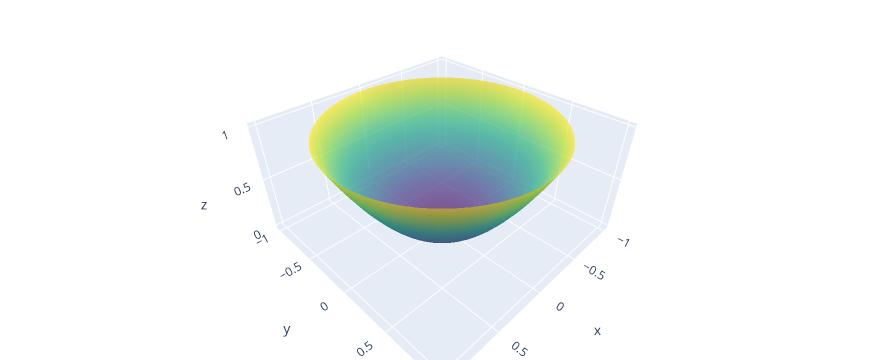

In [9]:
display_surface(psi, 0.0, 1, 0, 2*np.pi)

## Calcoliamo le soluzioni del problema di Cauchy delle traiettorie del moto libero

In [10]:
sol_u = solve_u(psi_d, u0=0.5, ell=1.0, E=1.0, t_span=(0,1))
sol_v = solve_v(sol_u, ell=1.0, v0=0.0)  

## Visualizziamo assieme la traiettoria e la superficie

In [11]:
display_surface_and_curve(                                
  psi, psi_d,
  a1=0.0, a2=1.0, b1=0, b2=2*np.pi,
  ell=1.0, E=1.0, u0=0.2, v0=0.0,                             
  t_span=(0, 0.2),                                             
  interactive=True,                                           
  ell_range=(0.1, 3.0),   # optional, defaults to [ell/5, ell*5]                                                          
  E_range=(0.1, 5.0),     # optional, defaults to [E/5, E*5]  
)

    'data': [{'colorscale': [[0.0, '#440154'], [0.1111111111111111, '#482878'],
…